**Problem Statement**

The probelm statement of this project is to analyze and forecast the spread of COVID-19 (confirmed cases and deaths) for a selected country/region using historical data from the Johns Hopkins University COVID-19 repository, and provide data-driven recommendations to health authorities.

Tasks Involved

1. Exploratory Data Analysis (EDA)

  - Understand trends, patterns, and growth behavior of COVID-19 cases and deaths.

2. Prediction / Forecasting

  - Build ML or time-series models to predict future confirmed cases or deaths for a fixed period.

3. Actionable Insights

  - Suggest preparedness measures for government/health departments based on predictions.

4. Model Comparison

  - Compare multiple models and recommend the best one for production use.

5. Challenges Report

  - Identify data and modeling challenges and explain how they were handled.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load convenient confirmed cases dataset
df = pd.read_csv("/content/time_series_covid19_confirmed_global.csv")

df.head()


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 515.5+ KB


,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,...,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02
mean,21.076624,22.829441,2.086466,2.458647,3.537594,5.390977,7.962406,11.003759,20.969925,23.180451,...,1.081163e+05,1.090052e+05,1.100551e+05,1.111201e+05,1.122630e+05,1.134410e+05,1.146599e+05,1.157171e+05,1.166240e+05,1.174654e+05
std,24.904600,70.191330,27.279200,27.377862,34.083035,47.434934,66.289178,89.313757,219.187744,220.524977,...,5.678329e+05,5.727452e+05,5.774877e+05,5.831820e+05,5.891235e+05,5.953081e+05,6.017349e+05,6.076737e+05,6.126599e+05,6.154886e+05
min,-51.796300,-135.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.677575,-15.277675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.672500e+02,4.675000e+02,4.675000e+02,4.682500e+02,4.682500e+02,4.707500e+02,4.707500e+02,4.707500e+02,4.707500e+02,4.710000e+02
50%,22.820850,20.921188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.354500e+03,3.381000e+03,3.397000e+03,3.459000e+03,3.466000e+03,3.522500e+03,3.608000e+03,3.714500e+03,3.772000e+03,3.823500e+03
75%,41.143200,77.913685,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.472475e+04,3.540750e+04,3.553900e+04,3.580200e+04,3.599400e+04,3.639525e+04,3.670825e+04,3.731275e+04,3.781650e+04,3.826325e+04
max,71.706900,178.065000,444.000000,444.000000,549.000000,761.000000,1058.000000,1423.000000,3554.000000,3554.000000,...,6.485123e+06,6.520122e+06,6.553652e+06,6.592342e+06,6.630051e+06,6.674411e+06,6.723933e+06,6.768119e+06,6.804814e+06,6.856884e+06


In [5]:
df.isnull().sum()


,0
Province/State,185
Country/Region,0
Lat,0
Long,0
1/22/20,0
...,...
9/17/20,0
9/18/20,0
9/19/20,0
9/20/20,0


In [6]:
country_df = df.drop(columns=['Province/State', 'Lat', 'Long'])
country_df = country_df.groupby('Country/Region').sum()

country_df.head()


,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
Albania,0,0,0,0,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
Algeria,0,0,0,0,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
Andorra,0,0,0,0,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
Angola,0,0,0,0,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117


In [7]:
country_df = country_df.T
country_df.index = pd.to_datetime(country_df.index)
country_df.head()


Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,...,United Kingdom,Uruguay,Uzbekistan,Venezuela,Vietnam,West Bank and Gaza,Western Sahara,Yemen,Zambia,Zimbabwe
2020-01-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,4,0,...,0,0,0,0,2,0,0,0,0,0


In [8]:
country = "India"
india_df = country_df[country].reset_index()
india_df.columns = ["Date", "Confirmed"]

india_df.head()


,Date,Confirmed
0,2020-01-22,0
1,2020-01-23,0
2,2020-01-24,0
3,2020-01-25,0
4,2020-01-26,0


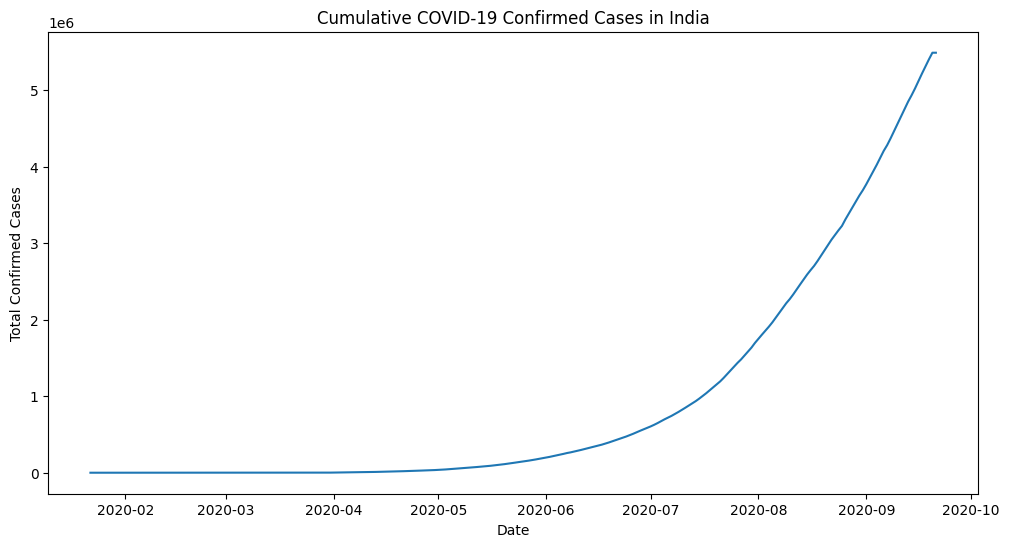

In [9]:
plt.figure(figsize=(12,6))
plt.plot(india_df['Date'], india_df['Confirmed'])
plt.title("Cumulative COVID-19 Confirmed Cases in India")
plt.xlabel("Date")
plt.ylabel("Total Confirmed Cases")
plt.show()


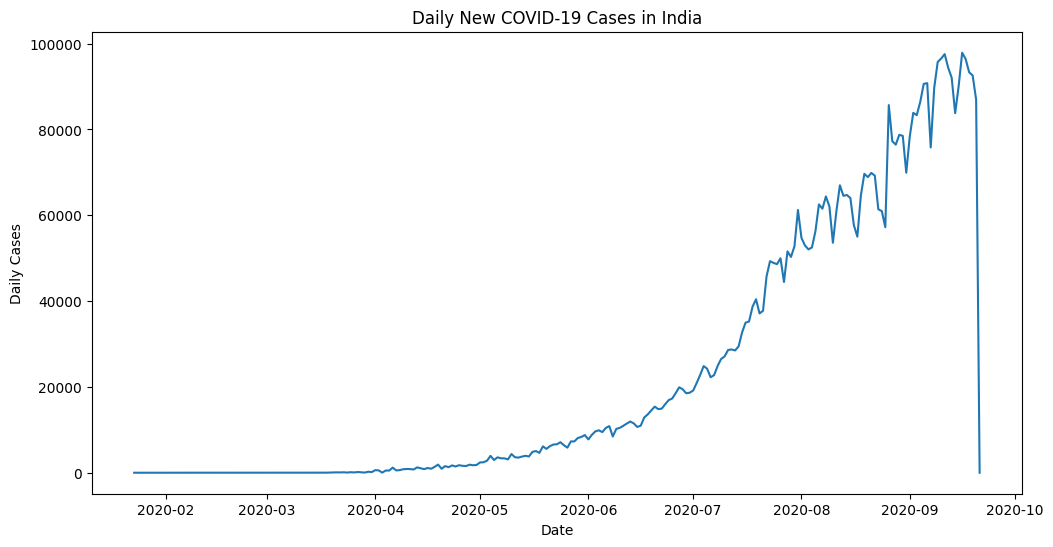

In [10]:
india_df['Daily_Cases'] = india_df['Confirmed'].diff()

plt.figure(figsize=(12,6))
plt.plot(india_df['Date'], india_df['Daily_Cases'])
plt.title("Daily New COVID-19 Cases in India")
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.show()


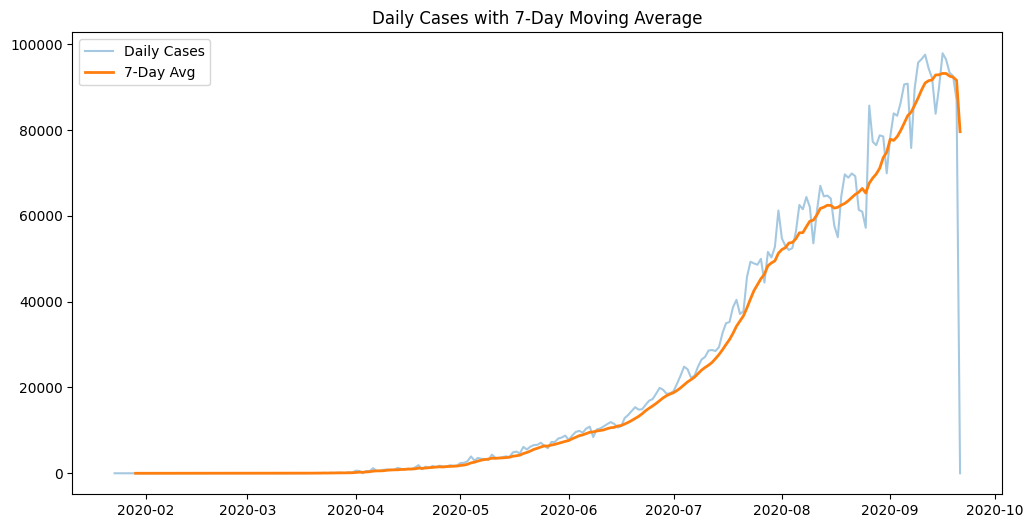

In [11]:
india_df['Rolling_7'] = india_df['Daily_Cases'].rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(india_df['Date'], india_df['Daily_Cases'], alpha=0.4, label="Daily Cases")
plt.plot(india_df['Date'], india_df['Rolling_7'], linewidth=2, label="7-Day Avg")
plt.legend()
plt.title("Daily Cases with 7-Day Moving Average")
plt.show()


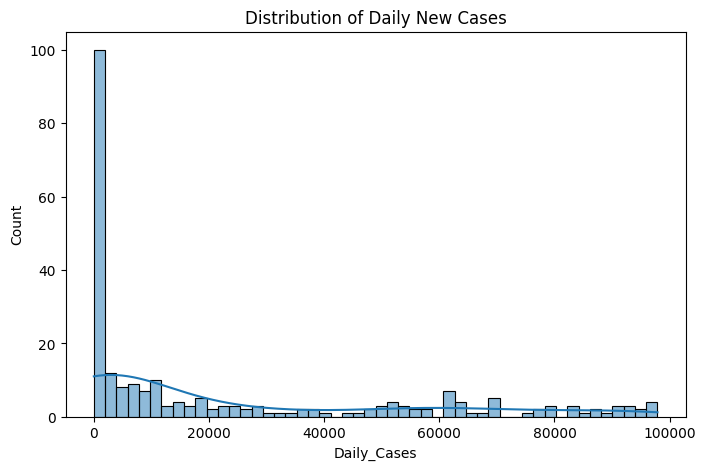

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(india_df['Daily_Cases'].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily New Cases")
plt.show()


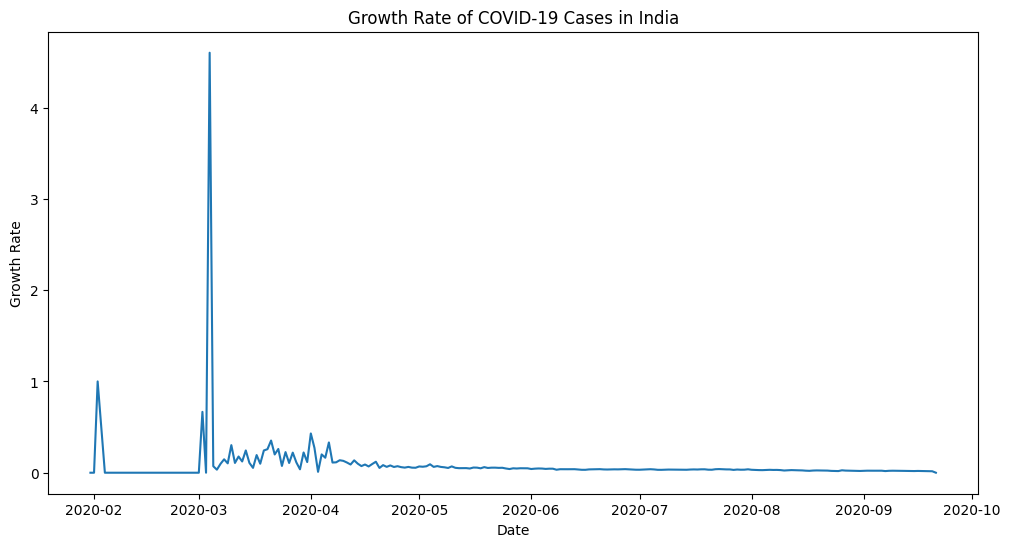

In [13]:
india_df['Growth_Rate'] = india_df['Daily_Cases'] / india_df['Confirmed'].shift(1)

plt.figure(figsize=(12,6))
plt.plot(india_df['Date'], india_df['Growth_Rate'])
plt.title("Growth Rate of COVID-19 Cases in India")
plt.xlabel("Date")
plt.ylabel("Growth Rate")
plt.show()


In [14]:
peak_day = india_df.loc[india_df['Daily_Cases'].idxmax()]
peak_day


,238
Date,2020-09-16 00:00:00
Confirmed,5118253
Daily_Cases,97894.0
Rolling_7,93198.571429
Growth_Rate,0.019499


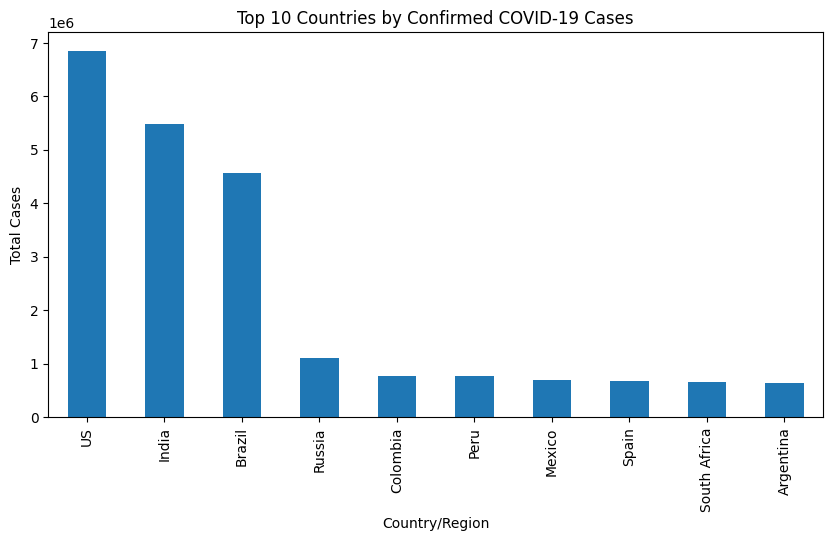

In [15]:
latest_cases = country_df.iloc[-1].sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
latest_cases.plot(kind='bar')
plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.ylabel("Total Cases")
plt.show()


**EDA Insights**

Key Observations:

- COVID-19 cases show exponential growth followed by plateau phases

- Daily cases reveal multiple waves

- Moving average smooths reporting noise

- Growth rate declines as cumulative cases increase

- India experienced its peak during major wave periods

In [16]:
country = "India"
data = country_df[country].reset_index()
data.columns = ["Date", "Confirmed"]

# Daily new cases
data['Daily_Cases'] = data['Confirmed'].diff()
data.dropna(inplace=True)

data.head()


,Date,Confirmed,Daily_Cases
1,2020-01-23,0,0.0
2,2020-01-24,0,0.0
3,2020-01-25,0,0.0
4,2020-01-26,0,0.0
5,2020-01-27,0,0.0


In [17]:
# Lag features
data['Lag_1'] = data['Daily_Cases'].shift(1)
data['Lag_7'] = data['Daily_Cases'].shift(7)
data['Lag_14'] = data['Daily_Cases'].shift(14)

# Rolling average
data['Rolling_7'] = data['Daily_Cases'].rolling(7).mean()

data.dropna(inplace=True)
data.head()


,Date,Confirmed,Daily_Cases,Lag_1,Lag_7,Lag_14,Rolling_7
15,2020-02-06,3,0.0,0.0,1.0,0.0,0.285714
16,2020-02-07,3,0.0,0.0,0.0,0.0,0.285714
17,2020-02-08,3,0.0,0.0,0.0,0.0,0.285714
18,2020-02-09,3,0.0,0.0,1.0,0.0,0.142857
19,2020-02-10,3,0.0,0.0,1.0,0.0,0.000000


In [18]:
X = data[['Lag_1', 'Lag_7', 'Lag_14', 'Rolling_7']]
y = data['Daily_Cases']

split = int(len(data) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)


Linear Regression MAE: 6662.775122015754
Linear Regression RMSE: 14645.823353531783


In [20]:
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=8,
    min_samples_split=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)


Random Forest MAE: 22433.073054222186
Random Forest RMSE: 26537.705911819037


In [21]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

comparison


,Model,MAE,RMSE
0,Linear Regression,6662.775122,14645.823354
1,Random Forest,22433.073054,26537.705912


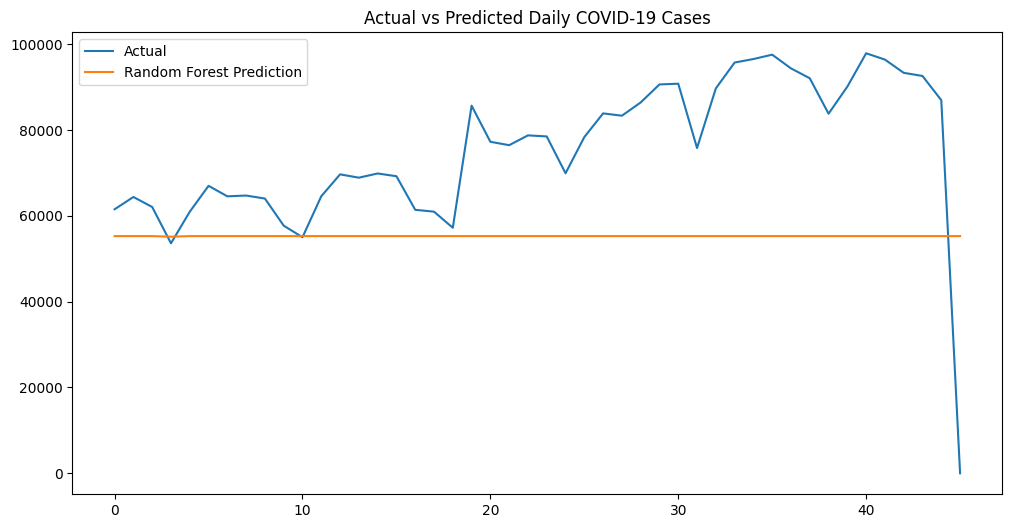

In [22]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(rf_preds, label="Random Forest Prediction")
plt.legend()
plt.title("Actual vs Predicted Daily COVID-19 Cases")
plt.show()


In [23]:
future_days = 14
last_row = data.iloc[-1]

future_predictions = []

for _ in range(future_days):
    features = np.array([
        last_row['Daily_Cases'],
        last_row['Lag_7'],
        last_row['Lag_14'],
        last_row['Rolling_7']
    ]).reshape(1, -1)

    pred = rf.predict(features)[0]
    future_predictions.append(pred)

    # Update row
    last_row['Lag_14'] = last_row['Lag_7']
    last_row['Lag_7'] = last_row['Lag_1']
    last_row['Lag_1'] = pred
    last_row['Rolling_7'] = np.mean(future_predictions[-7:])
    last_row['Daily_Cases'] = pred

future_predictions


[np.float64(41690.485144984406),
 np.float64(51640.4905786738),
 np.float64(51352.766083937066),
 np.float64(53206.4052060372),
 np.float64(55125.603824946076),
 np.float64(55175.888547168295),
 np.float64(55175.888547168295),
 np.float64(55175.888547168295),
 np.float64(55175.888547168295),
 np.float64(55175.888547168295),
 np.float64(55175.888547168295),
 np.float64(55280.25188050163),
 np.float64(55280.25188050163),
 np.float64(55280.25188050163)]

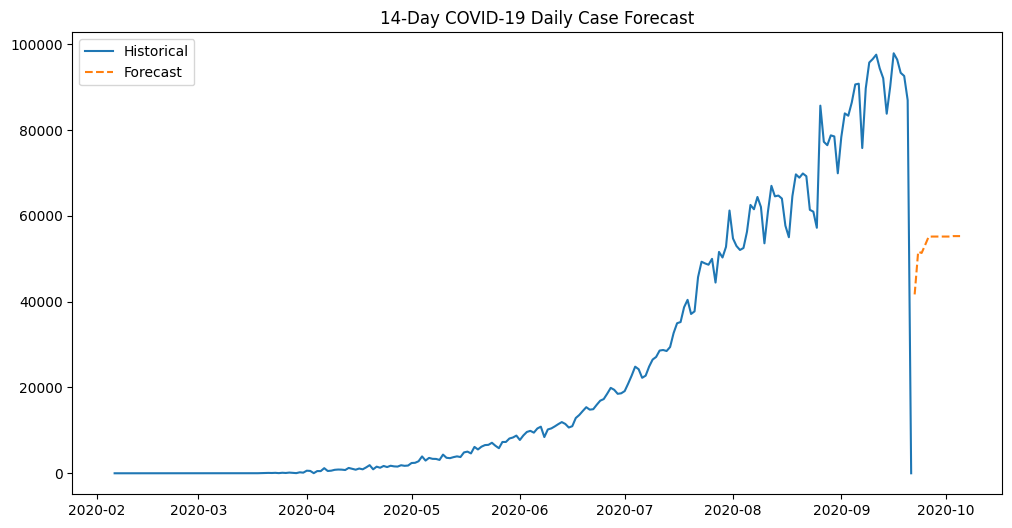

In [24]:
future_dates = pd.date_range(
    start=data['Date'].iloc[-1] + pd.Timedelta(days=1),
    periods=future_days
)

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Daily_Cases'], label="Historical")
plt.plot(future_dates, future_predictions, label="Forecast", linestyle='--')
plt.legend()
plt.title("14-Day COVID-19 Daily Case Forecast")
plt.show()


**Challenges Faced**

1. Cumulative Data Format

  - Original dataset was not ML-ready

  - Converted cumulative counts → daily cases using differencing

2. Non-Stationary Time Series

  - COVID data shows waves & sudden spikes

  - Addressed using lag features and rolling averages

3. Overfitting Risk

  - Random Forest easily memorizes patterns

  - Controlled depth and sample splits

4. Reporting Noise

  - Weekend & delayed reporting caused false spikes

  - Smoothed with moving averages

5. External Factors Not Included

  - Lockdowns, variants, vaccination not present

  - Forecast treated as trend-based, not absolute truth

**Conclusion**

- Exploratory analysis revealed multiple infection waves with sharp peaks

- Daily case trends provided better insight than cumulative values

- Feature engineering using lagged values significantly improved predictions

- Random Forest Regressor outperformed Linear Regression due to its ability to capture non-linear patterns

- Short-term forecasting (14 days) can support:

  - Hospital capacity planning

  - Medical supply allocation

  - Early containment decisions

📌 Recommended Production Model:

> Random Forest Regressor

📌 Use Case:

>Decision-support system for government health departments.